### Size issue 
That file size of 28.45 GB for a single-cell RNA-seq .h5ad dataset is very large.

Memory (RAM): A 28 GB .h5ad file, which typically contains a sparse matrix of UMI counts, will require a substantial amount of RAM when loaded and processed. When the data is converted to a dense matrix or intermediate processing steps are performed (like calculating nearest neighbors, running PCA, etc.), the memory footprint can easily exceed 100-200 GB.

Processing Time: Even with sufficient RAM, a dataset of this size (likely involving millions of cells) will result in long processing times for any single-cell workflow, particularly for computationally intensive steps like training a large neural network model such as GenFormer.

In [1]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import cellxgene_census
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

In [2]:
 adata = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/dataset.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 2096155 × 17267
    obs: 'n_genes', 'n_counts', 'Brain_bank', 'RIN', 'path_braak_lb', 'derived_class2', 'PMI', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_name', 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'genome', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'uid'
    obsm: 'X_umap'

In [ ]:
ada

In [5]:
adata.obs.head()

,n_genes,n_counts,Brain_bank,RIN,path_braak_lb,derived_class2,PMI,tissue_ontology_term_id,tissue_type,assay_ontology_term_id,...,suspension_type,is_primary_data,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
barcodekey,,,,,,,,,,,,,,,,,,,,,
Set10_C1-AAACCCACATCACGGC,2929,5645.0,UM,4.8,3,Oligo,20.91,UBERON:0002477,tissue,EFO:0009922,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,male,medial globus pallidus,European,82-year-old stage,MpT)aB)#*U
Set10_C1-AAACCCAGTAGCACAG,4395,14741.0,UD,4.4,3,Oligo,20.91,UBERON:0001384,tissue,EFO:0009922,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,qFT~wG^BCg
Set10_C1-AAACCCAGTATGTCCA,3856,11005.0,UM,4.8,3,Oligo,20.91,UBERON:0002477,tissue,EFO:0009922,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,male,medial globus pallidus,European,82-year-old stage,fE`VpY%8fb
Set10_C1-AAACCCAGTCCAGAAG,3387,8134.0,UD,4.4,3,Oligo,20.91,UBERON:0001384,tissue,EFO:0009922,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,g1Lr8^y)O(
Set10_C1-AAACCCATCCACGTAA,2366,4583.0,UD,4.4,3,Astro,20.91,UBERON:0001384,tissue,EFO:0009922,...,nucleus,True,astrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,MR9tUCifao


In [9]:
adata.obs['tissue']

barcodekey
Set10_C1-AAACCCACATCACGGC    medial globus pallidus
Set10_C1-AAACCCAGTAGCACAG      primary motor cortex
Set10_C1-AAACCCAGTATGTCCA    medial globus pallidus
Set10_C1-AAACCCAGTCCAGAAG      primary motor cortex
Set10_C1-AAACCCATCCACGTAA      primary motor cortex
                                      ...          
set7A_2-TTTGTTGTCAAGAGTA       primary motor cortex
set7A_2-TTTGTTGTCACTCTTA      primary visual cortex
set7A_2-TTTGTTGTCAGTGCGC       primary motor cortex
set7A_2-TTTGTTGTCGCCTATC       primary motor cortex
set7A_2-TTTGTTGTCTCTAGGA       primary motor cortex
Name: tissue, Length: 2096155, dtype: category
Categories (5, object): ['dorsal motor nucleus of vagus nerve' < 'medial globus pallidus' < 'primary motor cortex' < 'prefrontal cortex' < 'primary visual cortex']

In [7]:
adata.obs.columns

Index(['n_genes', 'n_counts', 'Brain_bank', 'RIN', 'path_braak_lb',
       'derived_class2', 'PMI', 'tissue_ontology_term_id', 'tissue_type',
       'assay_ontology_term_id', 'disease_ontology_term_id',
       'cell_type_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'donor_id', 'suspension_type', 'is_primary_data', 'cell_type', 'assay',
       'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid'],
      dtype='object')

In [17]:
adata.X[:10,:10].toarray()

array([[0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        2.9293141, 0.       , 0.       , 0.       ],
       [0.       , 0.       , 2.6787999, 0.       , 0.       , 3.5530312,
        0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 2.3112254, 0.       , 0.       , 0.       ,
        2.3112254, 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
        0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 3.1276271, 4.882185 , 0.       ,
        0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 2.4252477, 2.4252477,
        2.4252477, 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 2.918646 , 2.918646 ,
        0.       , 0.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.       , 0.       , 3.3781989,
        0.       , 0.       , 0.     

In [18]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 6609855574 stored elements and shape (2096155, 17267)>

In [6]:
adata.var.head()

,gene_name,n_cells,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
gene_id,,,,,,,,
ENSG00000186827,TNFRSF4,7846,False,TNFRSF4,NCBITaxon:9606,gene,1039,protein_coding
ENSG00000186891,TNFRSF18,9000,False,TNFRSF18,NCBITaxon:9606,gene,789,protein_coding
ENSG00000160072,ATAD3B,340777,False,ATAD3B,NCBITaxon:9606,gene,3300,protein_coding
ENSG00000041988,THAP3,209923,False,THAP3,NCBITaxon:9606,gene,931,protein_coding
ENSG00000142611,PRDM16,283396,False,PRDM16,NCBITaxon:9606,gene,3730,protein_coding


In [8]:
adata.var.columns

Index(['gene_name', 'n_cells', 'feature_is_filtered', 'feature_name',
       'feature_reference', 'feature_biotype', 'feature_length',
       'feature_type'],
      dtype='object')

In [10]:
adata.layers.keys()

KeysView(Layers with keys: )

In [11]:
adata.obsm.keys()

KeysView(AxisArrays with keys: X_umap)

In [12]:
adata.uns.keys()

dict_keys(['batch_condition', 'citation', 'genome', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'uid'])

In [22]:
adata.uns

{'batch_condition': array(['Brain_bank'], dtype=object),
 'citation': 'Publication: https://doi.org/10.1038/s41597-024-04117-y Dataset Version: https://datasets.cellxgene.cziscience.com/1f51228e-898e-474f-b8f2-5e7ad392b51c.h5ad curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/d5d0df8f-4eee-49d8-a221-a288f50a1590',
 'genome': 'GRCh38',
 'organism': 'Homo sapiens',
 'organism_ontology_term_id': 'NCBITaxon:9606',
 'schema_reference': 'https://github.com/chanzuckerberg/single-cell-curation/blob/main/schema/6.0.0/schema.md',
 'schema_version': '6.0.0',
 'title': "Parkinson's disease",
 'uid': 'GRCh38-rna'}

In [2]:
 metadata = pd.read_csv('/projects/bioinformatics/DB/scRNAseq_parkinson/metadata.csv')

In [20]:
metadata

,barcodekey,n_genes,n_counts,Brain_bank,RIN,path_braak_lb,derived_class2,PMI,tissue_ontology_term_id,tissue_type,...,suspension_type,is_primary_data,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
0,Set10_C1-AAACCCACATCACGGC,2929,5645.0,UM,4.8,3,Oligo,20.910000,UBERON:0002477,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,male,medial globus pallidus,European,82-year-old stage,MpT)aB)#*U
1,Set10_C1-AAACCCAGTAGCACAG,4395,14741.0,UD,4.4,3,Oligo,20.910000,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,qFT~wG^BCg
2,Set10_C1-AAACCCAGTATGTCCA,3856,11005.0,UM,4.8,3,Oligo,20.910000,UBERON:0002477,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,male,medial globus pallidus,European,82-year-old stage,fE`VpY%8fb
3,Set10_C1-AAACCCAGTCCAGAAG,3387,8134.0,UD,4.4,3,Oligo,20.910000,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,g1Lr8^y)O(
4,Set10_C1-AAACCCATCCACGTAA,2366,4583.0,UD,4.4,3,Astro,20.910000,UBERON:0001384,tissue,...,nucleus,True,astrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,MR9tUCifao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096150,set7A_2-TTTGTTGTCAAGAGTA,2976,6626.0,MSSM,4.7,1,Oligo,10.166667,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,normal,female,primary motor cortex,European,78-year-old stage,25FK4DT!Rl
2096151,set7A_2-TTTGTTGTCACTCTTA,3947,11414.0,MSSM,4.3,2,EN,10.166667,UBERON:0002436,tissue,...,nucleus,True,glutamatergic neuron,10x 3' v3,Parkinson disease,female,primary visual cortex,European,81-year-old stage,PdMVWS9R^v
2096152,set7A_2-TTTGTTGTCAGTGCGC,3212,8142.0,MSSM,3.0,4,Micro_PVM,10.166667,UBERON:0001384,tissue,...,nucleus,True,central nervous system macrophage,10x 3' v3,Parkinson disease,male,primary motor cortex,European,84-year-old stage,Q&?JBHEFAz
2096153,set7A_2-TTTGTTGTCGCCTATC,4442,12156.0,MSSM,4.7,1,OPC,10.166667,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte precursor cell,10x 3' v3,normal,female,primary motor cortex,European,78-year-old stage,@vUY6<XF#a


In [21]:
adata.raw


In [3]:
for col in metadata.columns:
    print("\n--------------------")
    print("Column:", col)
    print("Unique values:", metadata[col].nunique())
    print(metadata[col].unique()[:20])


--------------------
Column: barcodekey
Unique values: 2096155
['Set10_C1-AAACCCACATCACGGC' 'Set10_C1-AAACCCAGTAGCACAG'
 'Set10_C1-AAACCCAGTATGTCCA' 'Set10_C1-AAACCCAGTCCAGAAG'
 'Set10_C1-AAACCCATCCACGTAA' 'Set10_C1-AAACCCATCTGCTTAT'
 'Set10_C1-AAACGAAAGCGCACAA' 'Set10_C1-AAACGAAAGCTAATCC'
 'Set10_C1-AAACGAACAAGGTTGG' 'Set10_C1-AAACGAACAGAACTTC'
 'Set10_C1-AAACGAAGTGTTGCCG' 'Set10_C1-AAACGAATCCACTGAA'
 'Set10_C1-AAACGAATCCTGTACC' 'Set10_C1-AAACGAATCGACCTAA'
 'Set10_C1-AAACGAATCGCCACTT' 'Set10_C1-AAACGAATCGTAACCA'
 'Set10_C1-AAACGCTAGGGCCTCT' 'Set10_C1-AAACGCTCACGTAACT'
 'Set10_C1-AAACGCTCAGAACTAA' 'Set10_C1-AAACGCTCAGCTCCTT']

--------------------
Column: n_genes
Unique values: 11106
[2929 4395 3856 3387 2366 3727 2795 3482 3781 5025 4596 3023 3538 3910
 3868 3391 3633 4731 4089 2856]

--------------------
Column: n_counts
Unique values: 70803
[ 5645. 14741. 11005.  8134.  4583.  9705.  5710. 10595. 10884. 17836.
 17165.  9309. 10822. 10088. 11710.  7750. 10185. 16218. 12208.  7375.]


# Category Counts

In [4]:
for col in metadata.columns:
    
    if metadata[col].nunique() < 30:
        print("\n==========")
        print("Column:", col)
        print(metadata[col].value_counts())


Column: Brain_bank
Brain_bank
UM         667865
UD         544202
Harvard    455888
MSSM       428200
Name: count, dtype: int64

Column: path_braak_lb
path_braak_lb
4    552929
5    485372
3    381270
0    364445
6    160368
2     87778
1     63993
Name: count, dtype: int64

Column: derived_class2
derived_class2
Oligo        1093520
EN            328856
Astro         227452
IN            152393
Micro_PVM     118515
OPC           112585
Mural          17865
DMNX_Neu       14206
Ependymal      12559
Endo           11070
GPI_Neu         4773
Adaptive        2361
Name: count, dtype: int64

Column: tissue_ontology_term_id
tissue_ontology_term_id
UBERON:0000451    503414
UBERON:0001384    466475
UBERON:0002436    436737
UBERON:0002477    385587
UBERON:0002870    303942
Name: count, dtype: int64

Column: tissue_type
tissue_type
tissue    2096155
Name: count, dtype: int64

Column: assay_ontology_term_id
assay_ontology_term_id
EFO:0009922    2096155
Name: count, dtype: int64

Column: disease_o

In [5]:
summary = pd.DataFrame({
    "column": metadata.columns,
    "dtype": metadata.dtypes.values,
    "missing_values": metadata.isna().sum().values,
    "unique_values": metadata.nunique().values
})

summary.sort_values("unique_values")

,column,dtype,missing_values,unique_values
10,assay_ontology_term_id,object,0,1
9,tissue_type,object,0,1
18,is_primary_data,bool,0,1
17,suspension_type,object,0,1
20,assay,object,0,1
21,disease,object,0,2
15,sex_ontology_term_id,object,0,2
11,disease_ontology_term_id,object,0,2
22,sex,object,0,2
3,Brain_bank,object,0,4


In [6]:
pd.crosstab(metadata["cell_type"], metadata["disease"])

disease,Parkinson disease,normal
cell_type,,
GABAergic neuron,117025,35368
astrocyte,187024,40428
central nervous system macrophage,96514,22001
central nervous system neuron,15011,3968
endothelial cell,8584,2486
ependymal cell,10537,2022
glutamatergic neuron,249928,78928
leukocyte,1729,632
mural cell,13608,4257


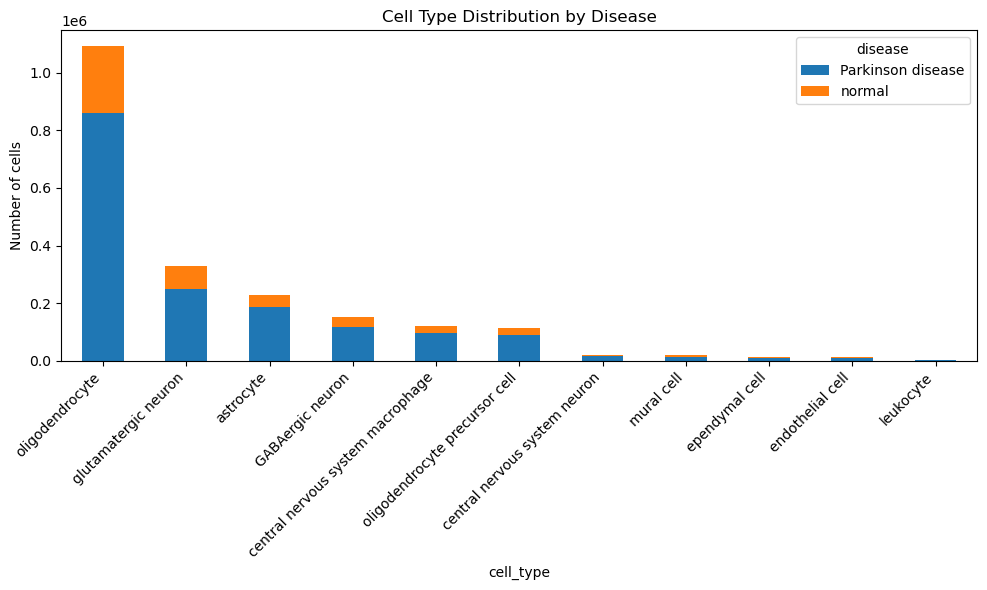

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Crosstab
ct = pd.crosstab(metadata["cell_type"], metadata["disease"])

# Sort by total number of cells (highest → lowest)
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# Plot
ct.plot(kind="bar", stacked=True, figsize=(10,6))

plt.ylabel("Number of cells")
plt.title("Cell Type Distribution by Disease")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

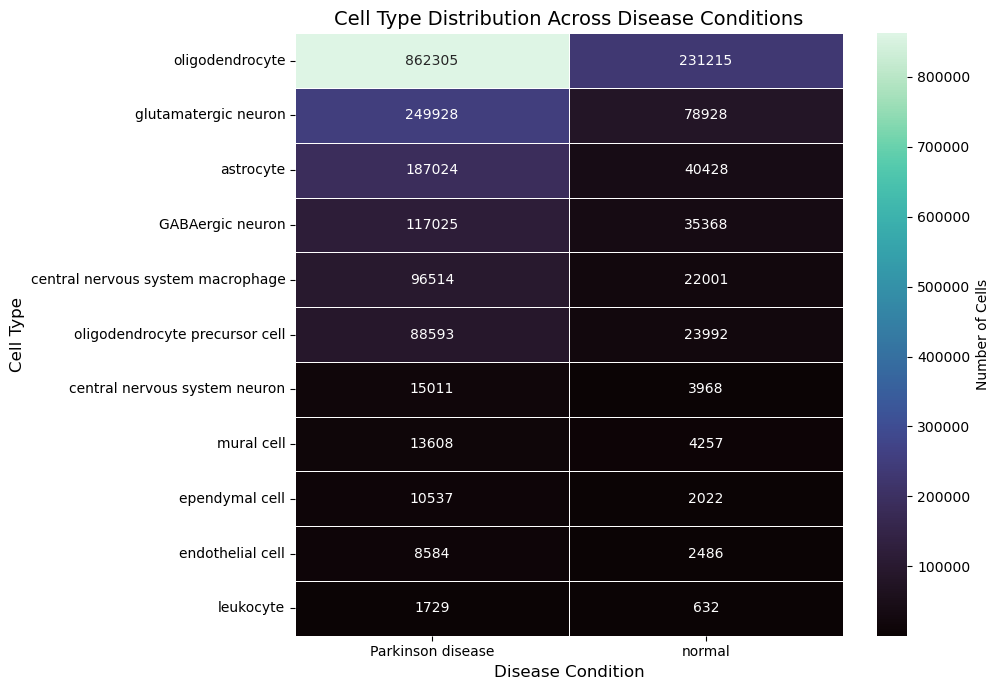

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab
ct = pd.crosstab(metadata["cell_type"], metadata["disease"])

# Sort cell types by total cell count
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]

# Plot
plt.figure(figsize=(10,7))

sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="mako",   # much clearer than viridis
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of Cells"}
)

plt.title("Cell Type Distribution Across Disease Conditions", fontsize=14)
plt.ylabel("Cell Type", fontsize=12)
plt.xlabel("Disease Condition", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

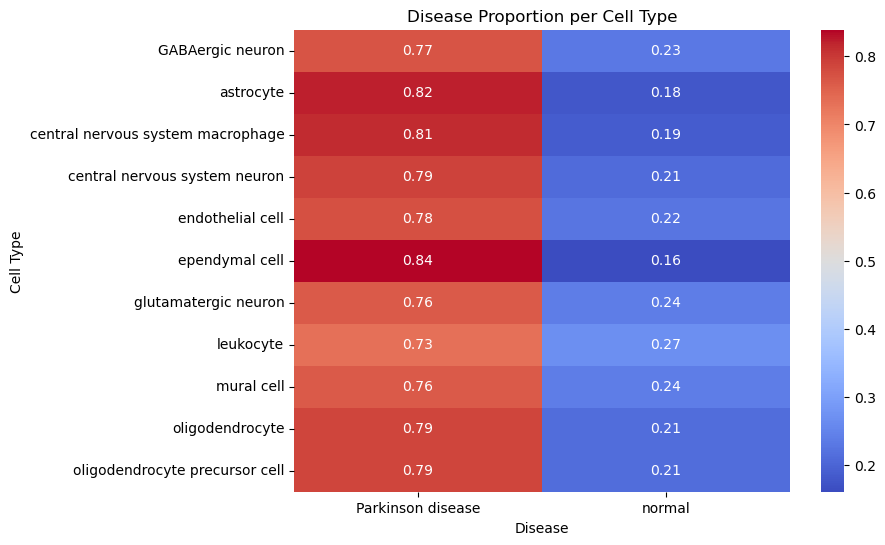

In [10]:
ct = pd.crosstab(metadata["cell_type"], metadata["disease"])

ct_norm = ct.div(ct.sum(axis=1), axis=0)

plt.figure(figsize=(8,6))

sns.heatmap(ct_norm, annot=True, cmap="coolwarm")

plt.title("Disease Proportion per Cell Type")
plt.ylabel("Cell Type")
plt.xlabel("Disease")

plt.show()

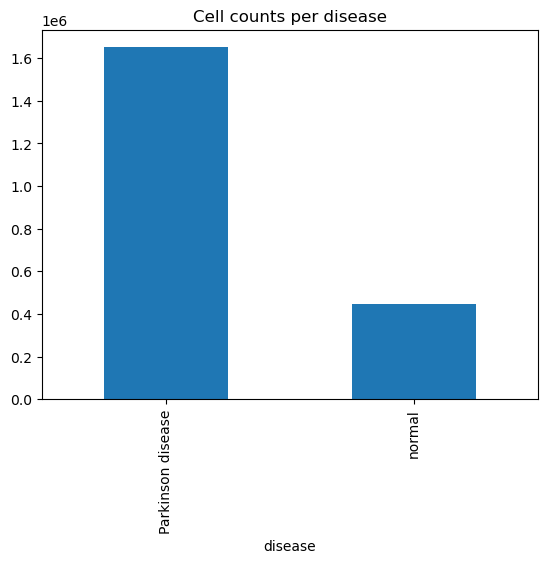

In [7]:
import matplotlib.pyplot as plt

metadata["disease"].value_counts().plot.bar()
plt.title("Cell counts per disease")
plt.show()

/var/tmp/pbs.417911.pbs01/ipykernel_111026/4291125498.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


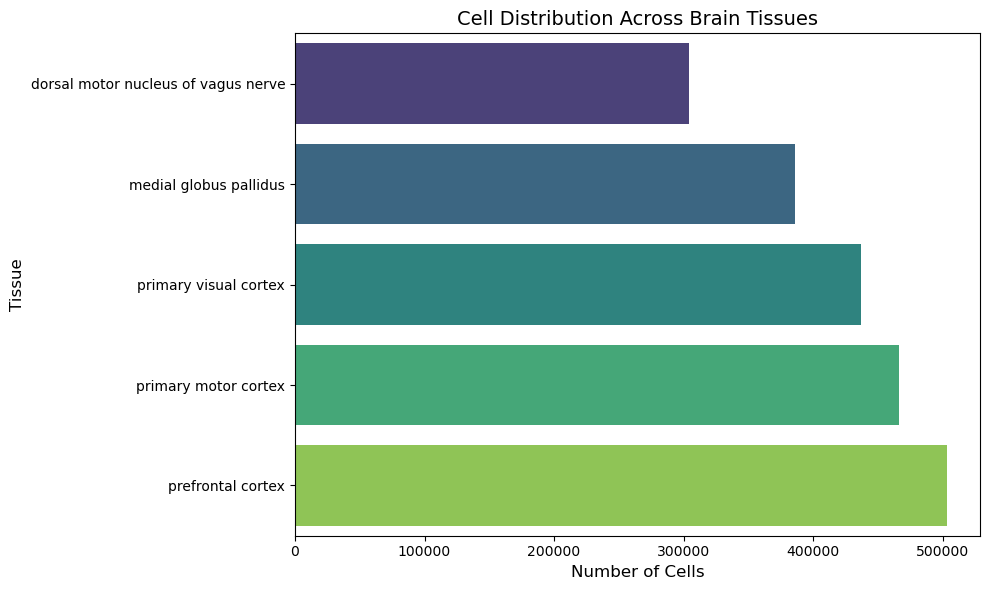

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count tissues
tissue_counts = metadata["tissue"].value_counts()

# Sort highest → lowest
tissue_counts = tissue_counts.sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x=tissue_counts.values,
    y=tissue_counts.index,
    palette="viridis"
)

plt.xlabel("Number of Cells", fontsize=12)
plt.ylabel("Tissue", fontsize=12)
plt.title("Cell Distribution Across Brain Tissues", fontsize=14)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd

# Extract numeric age
metadata["age"] = metadata["development_stage"].str.extract(r"(\d+)").astype(int)

# Check
metadata[["development_stage","age"]].head()

,development_stage,age
0,82-year-old stage,82
1,73-year-old stage,73
2,82-year-old stage,82
3,73-year-old stage,73
4,73-year-old stage,73


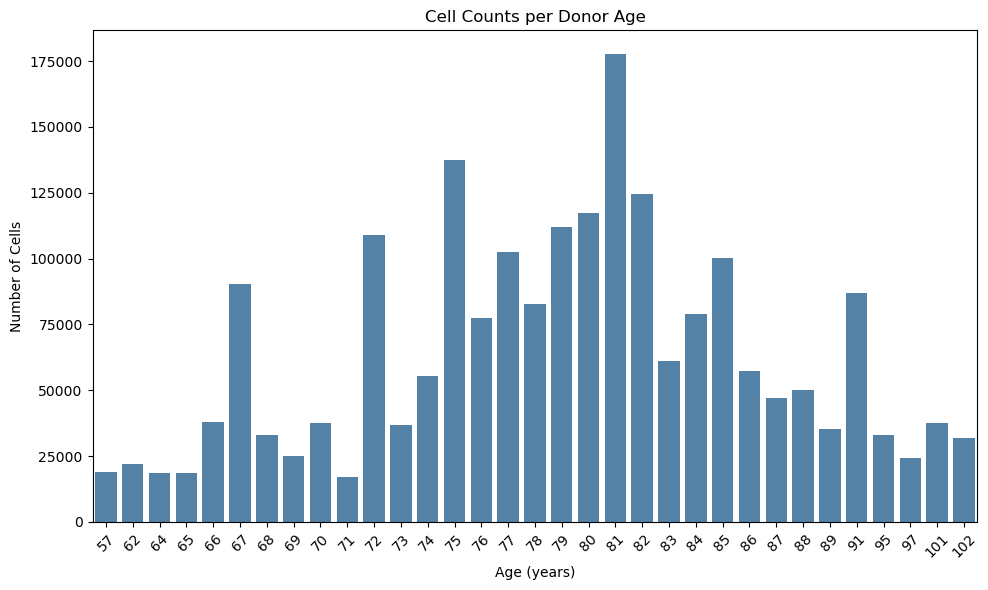

In [18]:
age_counts = metadata["age"].value_counts().sort_index()

plt.figure(figsize=(10,6))

sns.barplot(
    x=age_counts.index,
    y=age_counts.values,
    color="steelblue"
)

plt.xlabel("Age (years)")
plt.ylabel("Number of Cells")
plt.title("Cell Counts per Donor Age")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()